In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

In [2]:
omni = pd.read_csv("omni2_all_years.dat.txt", 
                   sep ='\s+', 
                   header = None)

omni.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,1963,1,0,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
1,1963,1,1,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
2,1963,1,2,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
3,1963,1,3,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9
4,1963,1,4,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9


In [3]:
omni.shape

(552264, 55)

In [4]:
colnames = [
    "Year",                     # 1
    "Day",                      # 2
    "Hour",                     # 3
    "Bartels_Rotation",         # 4
    "ID_IMF_SC",                # 5
    "ID_SW_SC",                 # 6
    "N_IMF_Avg",                # 7
    "N_Plasma_Avg",             # 8
    "Field_Mag_Avg",            # 9
    "Field_Mag_Vector",         # 10
    "Field_Lat",                # 11
    "Field_Lon",                # 12
    "Bx_GSE",                   # 13
    "By_GSE",                   # 14
    "Bz_GSE",                   # 15
    "By_GSM",                   # 16
    "Bz_GSM",                   # 17
    "Sigma_Field_Mag",          # 18
    "Sigma_Field_Vector",       # 19
    "Sigma_Bx",                 # 20
    "Sigma_By",                 # 21
    "Sigma_Bz",                 # 22
    "Proton_Temperature",       # 23
    "Proton_Density",           # 24
    "Plasma_Speed",               # 25
    "Plasma_Flow_Longitude",      # 26
    "Plasma_Flow_Latitude",       # 27
    "Alpha_Proton_Ratio",       # 28
    "Flow_Pressure",            # 29
    "Sigma_Temperature",        # 30
    "Sigma_Density",            # 31
    "Sigma_Speed",              # 32
    "Sigma_Flow_Longitude",     # 33
    "Sigma_Flow_Latitude",      # 34
    "Sigma_Ratio",              # 35
    "Electric_Field",           # 36
    "Plasma_Beta",              # 37
    "Alfven_Mach_Number",       # 38
    "Kp_x10",                   # 39
    "Sunspot_Number",           # 40
    "Dst",                      # 41
    "AE",                       # 42
    "Proton_Flux_GT_1MeV",      # 43
    "Proton_Flux_GT_2MeV",      # 44
    "Proton_Flux_GT_4MeV",      # 45
    "Proton_Flux_GT_10MeV",     # 46
    "Proton_Flux_GT_30MeV",     # 47
    "Proton_Flux_GT_60MeV",     # 48
    "Msph_Flux_Flag",           # 49
    "ap_index",                 # 50
    "F10_7",                    # 51
    "PC_N",                     # 52
    "AL",                       # 53
    "AU",                       # 54
    "Magnetosonic_Mach"         # 55
]

omni.columns = colnames

omni.head()

,Year,Day,Hour,Bartels_Rotation,ID_IMF_SC,ID_SW_SC,N_IMF_Avg,N_Plasma_Avg,Field_Mag_Avg,Field_Mag_Vector,...,Proton_Flux_GT_10MeV,Proton_Flux_GT_30MeV,Proton_Flux_GT_60MeV,Msph_Flux_Flag,ap_index,F10_7,PC_N,AL,AU,Magnetosonic_Mach
0,1963,1,0,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
1,1963,1,1,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
2,1963,1,2,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
3,1963,1,3,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9
4,1963,1,4,1771,99,99,999,999,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9


In [5]:
omni["Datetime"] = pd.to_datetime(omni["Year"].astype(str), format = "%Y") + \
                   pd.to_timedelta(omni["Day"] - 1, unit = "D") + \
                   pd.to_timedelta(omni['Hour'], unit = "h")

omni = omni.set_index("Datetime")

drop_dates = ["Year",
              "Day",
              "Hour"]

omni.drop(drop_dates, axis = "columns", inplace = True)

In [6]:
omni.head()

,Bartels_Rotation,ID_IMF_SC,ID_SW_SC,N_IMF_Avg,N_Plasma_Avg,Field_Mag_Avg,Field_Mag_Vector,Field_Lat,Field_Lon,Bx_GSE,...,Proton_Flux_GT_10MeV,Proton_Flux_GT_30MeV,Proton_Flux_GT_60MeV,Msph_Flux_Flag,ap_index,F10_7,PC_N,AL,AU,Magnetosonic_Mach
Datetime,,,,,,,,,,,,,,,,,,,,,
1963-01-01 00:00:00,1771,99,99,999,999,999.9,999.9,999.9,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
1963-01-01 01:00:00,1771,99,99,999,999,999.9,999.9,999.9,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
1963-01-01 02:00:00,1771,99,99,999,999,999.9,999.9,999.9,999.9,999.9,...,99999.99,99999.99,99999.99,0,3,999.9,999.9,99999,99999,99.9
1963-01-01 03:00:00,1771,99,99,999,999,999.9,999.9,999.9,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9
1963-01-01 04:00:00,1771,99,99,999,999,999.9,999.9,999.9,999.9,999.9,...,99999.99,99999.99,99999.99,0,7,999.9,999.9,99999,99999,99.9


In [7]:
fill_values = {
    "Bartels_Rotation": 9999,         # 4
    "ID_IMF_SC": 99,                # 5
    "ID_SW_SC": 99,                 # 6
    "N_IMF_Avg": 999,                # 7
    "N_Plasma_Avg": 999,             # 8
    "Field_Mag_Avg": 999.9,            # 9
    "Field_Mag_Vector": 999.9,         # 10
    "Field_Lat": 999.9,                # 11
    "Field_Lon": 999.9,                # 12
    "Bx_GSE": 999.9,                   # 13
    "By_GSE": 999.9,                   # 14
    "Bz_GSE": 999.9,                   # 15
    "By_GSM": 999.9,                   # 16
    "Bz_GSM": 999.9,                   # 17
    "Sigma_Field_Mag": 999.9,          # 18
    "Sigma_Field_Vector": 999.9,       # 19
    "Sigma_Bx": 999.9,                 # 20
    "Sigma_By": 999.9,                 # 21
    "Sigma_Bz": 999.9,                 # 22
    "Proton_Temperature": 9999999.0,       # 23
    "Proton_Density": 999.9,           # 24
    "Plasma_Speed": 9999.0,               # 25
    "Plasma_Flow_Longitude": 999.9,      # 26
    "Plasma_Flow_Latitude": 999.9,       # 27
    "Alpha_Proton_Ratio": 9.999,       # 28
    "Flow_Pressure": 99.99,            # 29
    "Sigma_Temperature": 9999999.0,        # 30
    "Sigma_Density": 999.9,            # 31
    "Sigma_Speed": 9999.0,              # 32
    "Sigma_Flow_Longitude": 999.9,     # 33
    "Sigma_Flow_Latitude": 999.9,      # 34
    "Sigma_Ratio": 9.999,              # 35
    "Electric_Field": 999.99,           # 36
    "Plasma_Beta": 999.99,              # 37
    "Alfven_Mach_Number": 999.9,       # 38
    "Kp_x10": 99,                   # 39
    "Sunspot_Number": 999,           # 40
    "Dst": 99999,                      # 41
    "AE": 9999,                       # 42
    "Proton_Flux_GT_1MeV": 999999.99,      # 43
    "Proton_Flux_GT_2MeV": 99999.99,      # 44
    "Proton_Flux_GT_4MeV": 99999.99,      # 45
    "Proton_Flux_GT_10MeV": 99999.99,     # 46
    "Proton_Flux_GT_30MeV": 99999.99,     # 47
    "Proton_Flux_GT_60MeV": 99999.99,     # 48
    "Msph_Flux_Flag": 0,           # 49
    "ap_index": 999,                 # 50
    "F10_7": 999.9,                    # 51
    "PC_N": 999.9,                     # 52
    "AL": 99999,                       # 53
    "AU": 99999,                       # 54
    "Magnetosonic_Mach": 99.9         # 55
}

for col, value in fill_values.items():
    if col in omni.columns:
        omni[col] = omni[col].replace(value, np.nan)

In [8]:
omni.describe().T

,count,mean,std,min,25%,50%,75%,max
Bartels_Rotation,550776.0,2196.185193,245.363665,1771.00,1984.000,2196.000,2409.000,2621.000
ID_IMF_SC,426551.0,46.759703,15.907277,1.00,50.000,51.000,51.000,71.000
ID_SW_SC,422477.0,50.034991,16.008285,1.00,50.000,52.000,52.000,98.000
N_IMF_Avg,404614.0,58.103768,70.069230,1.00,33.000,59.000,60.000,997.000
N_Plasma_Avg,407765.0,28.481213,13.266686,1.00,16.000,34.000,37.000,290.000
Field_Mag_Avg,426551.0,6.170448,3.167803,0.40,4.200,5.500,7.300,68.900
Field_Mag_Vector,426551.0,5.491759,3.047824,0.10,3.600,4.800,6.600,67.800
Field_Lat,426551.0,-0.292618,28.753869,-89.80,-18.400,0.000,17.900,90.000
Field_Lon,426551.0,202.937440,101.226702,-90.00,123.300,184.000,303.200,360.000
Bx_GSE,426551.0,0.031790,3.681207,-40.80,-2.700,0.100,2.700,34.800


<Axes: >

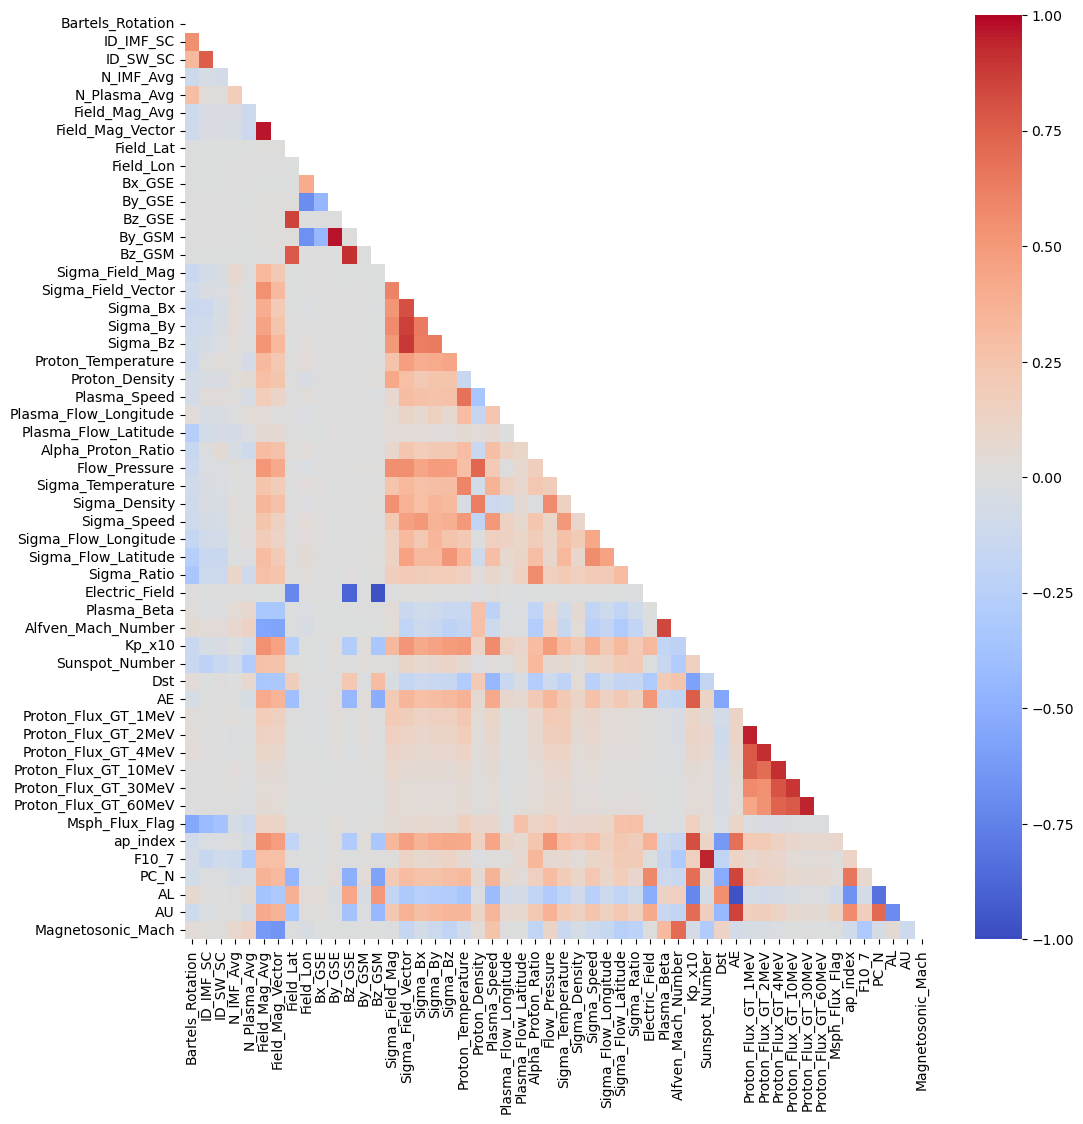

In [9]:
correlation_matrix = omni.corr()
plt.figure(figsize = (12, 12))

mask = np.triu(np.ones_like(correlation_matrix, dtype = bool))
sns.heatmap(correlation_matrix,
            annot = False,
            cmap = "coolwarm",
            vmin = -1,
            vmax = 1,
            mask = mask)

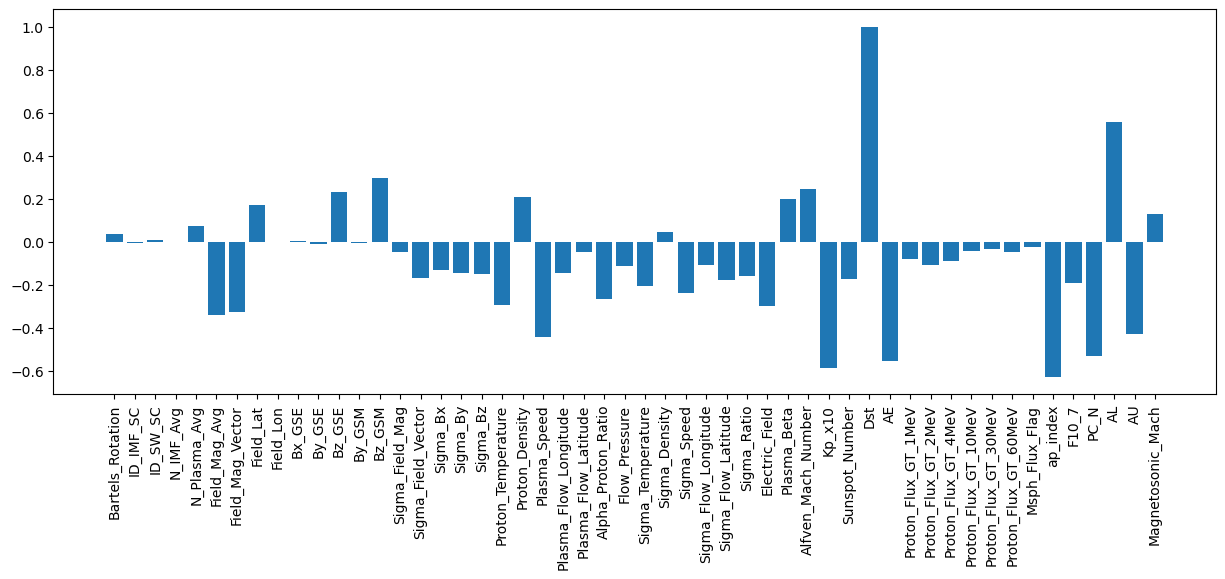

In [10]:
plt.figure(figsize = (15, 5))
plt.bar(omni.columns, correlation_matrix["Dst"])
plt.xticks(rotation = 90)
plt.show()

In [11]:
abs(correlation_matrix["Dst"]).sort_values(ascending = False)

Dst                      1.000000
ap_index                 0.627224
Kp_x10                   0.585241
AE                       0.556252
AL                       0.554617
PC_N                     0.528973
Plasma_Speed             0.441735
AU                       0.430624
Field_Mag_Avg            0.339705
Field_Mag_Vector         0.325405
Electric_Field           0.298534
Bz_GSM                   0.298456
Proton_Temperature       0.294737
Alpha_Proton_Ratio       0.265785
Alfven_Mach_Number       0.247488
Sigma_Speed              0.236850
Bz_GSE                   0.229384
Proton_Density           0.206582
Sigma_Temperature        0.204671
Plasma_Beta              0.198567
F10_7                    0.190114
Sigma_Flow_Latitude      0.179482
Sunspot_Number           0.175045
Field_Lat                0.172229
Sigma_Field_Vector       0.167079
Sigma_Ratio              0.157182
Sigma_Bz                 0.150158
Sigma_By                 0.147186
Plasma_Flow_Longitude    0.143081
Sigma_Bx      

In [12]:
key_features = [
    "Dst", 
    "Bz_GSM", 
    "Bz_GSE",
    "Plasma_Speed", 
    "Field_Mag_Avg",
    "Proton_Density"
]

omni_key = omni[key_features]

omni_key.shape

(552264, 6)

In [13]:
omni_key.describe().T

,count,mean,std,min,25%,50%,75%,max
Dst,550790.0,-14.194348,22.101416,-589.0,-22.0,-10.0,-1.0,81.0
Bz_GSM,426525.0,-0.018502,3.145633,-57.8,-1.6,0.0,1.5,41.6
Bz_GSE,426551.0,-0.003532,2.995251,-53.7,-1.4,0.0,1.4,37.5
Plasma_Speed,422473.0,433.481072,101.702388,156.0,358.0,410.0,489.0,1189.0
Field_Mag_Avg,426551.0,6.170448,3.167803,0.4,4.2,5.5,7.3,68.9
Proton_Density,406152.0,6.660356,5.406731,0.0,3.3,5.1,8.2,137.2


In [14]:
target = omni_key["Dst"]
features = omni_key.drop("Dst", axis = 1)

lag_features = []

for col in features.columns:
    for lag in range(9, -1,-1):
        lag_features.append(features[col].shift(lag).rename(f"{col}_t-{lag}"))

max_lag = 10
horizon = 3

omni_target = target.shift(-horizon).rename("Dst_t+3")

omni_features = pd.DataFrame(lag_features).transpose()

omni_lagged = pd.concat([omni_features, omni_target], axis=1)

start = max_lag
end = len(omni_lagged) - horizon
omni_lagged = omni_lagged.iloc[start:end].copy()

In [15]:
omni_lagged.head()

,Bz_GSM_t-9,Bz_GSM_t-8,Bz_GSM_t-7,Bz_GSM_t-6,Bz_GSM_t-5,Bz_GSM_t-4,Bz_GSM_t-3,Bz_GSM_t-2,Bz_GSM_t-1,Bz_GSM_t-0,...,Proton_Density_t-8,Proton_Density_t-7,Proton_Density_t-6,Proton_Density_t-5,Proton_Density_t-4,Proton_Density_t-3,Proton_Density_t-2,Proton_Density_t-1,Proton_Density_t-0,Dst_t+3
Datetime,,,,,,,,,,,,,,,,,,,,,
1963-01-01 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.0
1963-01-01 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.0
1963-01-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11.0
1963-01-01 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.0
1963-01-01 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-16.0


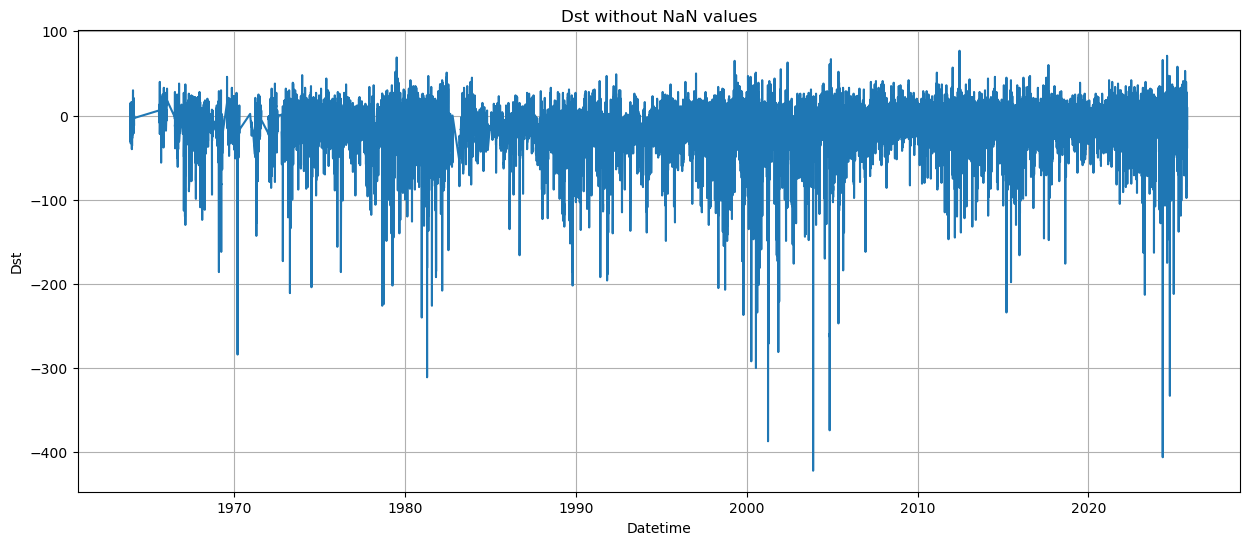

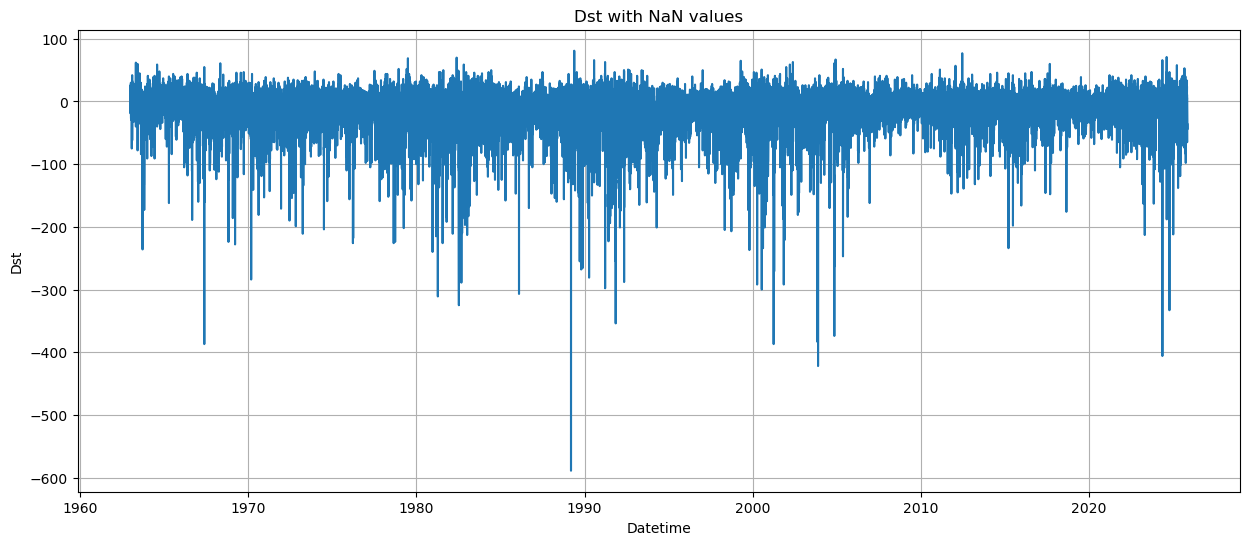

In [16]:
omni_lagged_dropped = omni_lagged.dropna()

plt.figure(figsize = (15,6))
plt.grid(0.5)
plt.title("Dst without NaN values")
plt.plot(omni_lagged_dropped.index, omni_lagged_dropped["Dst_t+3"])
plt.xlabel("Datetime")
plt.ylabel("Dst")
plt.show()

plt.figure(figsize = (15,6))
plt.grid(0.5)
plt.title("Dst with NaN values")
plt.plot(omni_lagged.index, omni_lagged["Dst_t+3"])
plt.xlabel("Datetime")
plt.ylabel("Dst")
plt.show()

In [17]:
imputer = KNNImputer(n_neighbors = 5)

storms_list = []
storm_no = 100
found = 0

"""temp_omni_lagged = omni_lagged_dropped.copy()"""
temp_omni_lagged = omni_lagged.copy()


while found < storm_no:
    search_series = temp_omni_lagged["Dst_t+3"]

    if search_series.empty:
      break

    window_center_time = search_series.idxmin()

    window_start = window_center_time - pd.Timedelta(days = 2)
    window_end = window_center_time + pd.Timedelta(days = 2)

    window = omni_lagged.loc[window_start:window_end].copy()

    consecutive_nans = any(
      window[col].isna().rolling(5).sum().eq(5).any()
      for col in window.columns
    )

    if consecutive_nans:
      temp_omni_lagged.loc[window_start:window_end, "Dst_t+3"] = np.nan
      continue

    nan_threshold = 0.1
    
    if window.isna().mean().max() > nan_threshold:
      temp_omni_lagged.loc[window_start:window_end, "Dst_t+3"] = np.nan
      continue

    expected_length = 97
    if len(window) != expected_length:
      temp_omni_lagged.loc[window_start:window_end, "Dst_t+3"] = np.nan
      continue

    found += 1
    window_imputed = pd.DataFrame(
      imputer.fit_transform(window),
      columns=window.columns,
      index=window.index
    )

    window_imputed["storm_number"] = found
    storms_list.append(window_imputed)

    removal_start = window_center_time - pd.Timedelta(days = 2)
    removal_end = window_center_time + pd.Timedelta(days = 2)
    temp_omni_lagged.loc[removal_start:removal_end, "Dst_t+3"] = np.nan

storms = pd.concat(storms_list)

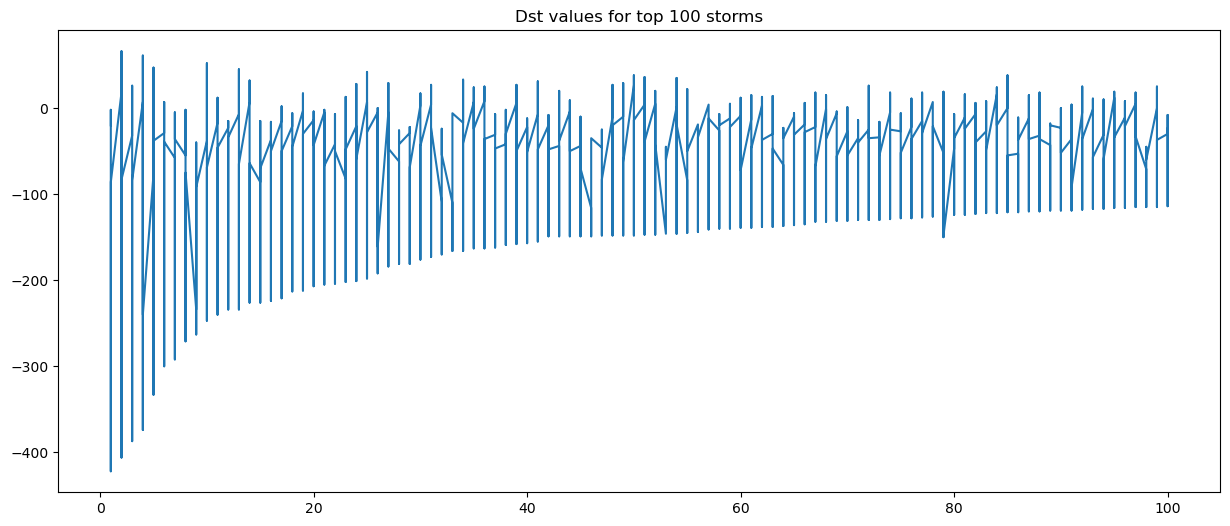

In [18]:
plt.figure(figsize = (15,6))
plt.title("Dst values for top 100 storms")
plt.plot(storms["storm_number"], storms["Dst_t+3"])
plt.show()

<Axes: >

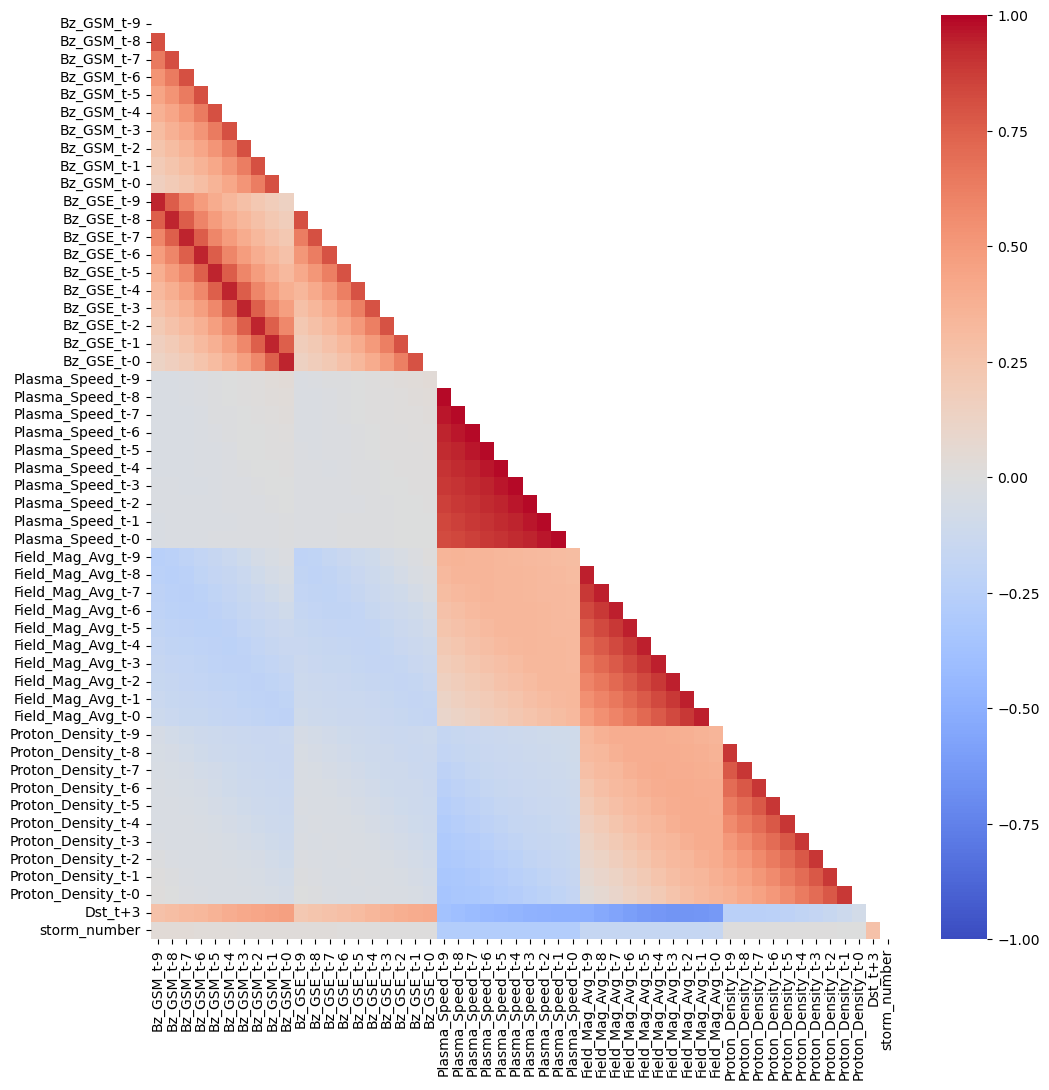

In [19]:
correlation_matrix_2 = storms.corr()
plt.figure(figsize = (12, 12))

mask = np.triu(np.ones_like(correlation_matrix_2, dtype = bool))

sns.heatmap(correlation_matrix_2,
            annot = False,
            cmap = "coolwarm",
            vmin = -1,
            vmax = 1,
            mask = mask)

In [ ]:
"""storms.to_csv("storm_dataset.csv", index = True)"""
"""storms.to_csv("storm_dataset_96.csv", index = True)"""

In [21]:
for i in range(1, storm_no + 1):
    print(storms[storms["storm_number"] == i].shape)

(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
(97, 52)
